In [1]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import mlflow
import mlflow.sklearn

print("All libraries imported successfully!")
print("MLflow version:", mlflow.__version__)

All libraries imported successfully!
MLflow version: 3.15.1


In [3]:
# Load dataset
data = load_diabetes()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget statistics:")
print(y.describe())

Dataset Shape: (442, 10)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Target statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [5]:
# Create baseline linear regression model
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train
linear_model.fit(X_train, y_train)

# Predictions
y_pred = linear_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance
-----------------------------
MSE : 2900.1936
MAE : 42.7941
R²  : 0.4526


In [6]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("----------------------------")
print(f"MSE : {ridge_mse:.4f}")
print(f"MAE : {ridge_mae:.4f}")
print(f"R²  : {ridge_r2:.4f}")

Ridge Regression Performance
----------------------------
MSE : 2892.0146
MAE : 42.8120
R²  : 0.4541


In [7]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Performance")
print("----------------------------")
print(f"MSE : {lasso_mse:.4f}")
print(f"MAE : {lasso_mae:.4f}")
print(f"R²  : {lasso_r2:.4f}")

Lasso Regression Performance
----------------------------
MSE : 2884.6243
MAE : 42.8052
R²  : 0.4555


In [8]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE": [
        mse,
        ridge_mse,
        lasso_mse
    ],
    "MAE": [
        mae,
        ridge_mae,
        lasso_mae
    ],
    "R2": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

display(comparison)

,Model,MSE,MAE,R2
0,Linear Regression,2900.193628,42.794095,0.452603
1,Ridge Regression,2892.014566,42.811999,0.454147
2,Lasso Regression,2884.624289,42.805234,0.455541


In [9]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest CV Score:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'model__alpha': 10}

Best CV Score:
-3127.9971985368697


In [10]:
best_ridge = ridge_grid.best_estimator_

ridge_test_pred = best_ridge.predict(X_test)

ridge_test_mse = mean_squared_error(
    y_test,
    ridge_test_pred
)

ridge_test_r2 = r2_score(
    y_test,
    ridge_test_pred
)

print("Best Ridge Model")
print("----------------")
print(f"Test MSE: {ridge_test_mse:.4f}")
print(f"Test R² : {ridge_test_r2:.4f}")

Best Ridge Model
----------------
Test MSE: 2875.7787
Test R² : 0.4572


In [11]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        0.5,
        1,
        10
    ]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Parameters:")
print(lasso_grid.best_params_)

print("\nBest CV Score:")
print(lasso_grid.best_score_)

Best Lasso Parameters:
{'model__alpha': 1}

Best CV Score:
-3130.458031073008


In [12]:
from scipy.stats import loguniform

ridge_random = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

random_param_dist = {
    "model__alpha": loguniform(0.001, 1000)
}

random_search = RandomizedSearchCV(
    estimator=ridge_random,
    param_distributions=random_param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Randomized Search Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Randomized Search Parameters:
{'model__alpha': np.float64(24.658329458549105)}

Best CV Score:
-3121.413019685561


In [13]:
print("Grid Search")
print("-----------")
print("Best Alpha:", ridge_grid.best_params_["model__alpha"])

print("\nRandomized Search")
print("-----------------")
print("Best Alpha:", random_search.best_params_["model__alpha"])

Grid Search
-----------
Best Alpha: 10

Randomized Search
-----------------
Best Alpha: 24.658329458549105


In [14]:
cv_scores = cross_val_score(
    best_ridge,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean CV R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation R² Scores:
[0.53988382 0.37610142 0.49973558 0.61034657 0.24361968]

Mean CV R²: 0.45393741579593494
Standard Deviation: 0.12979990217231227


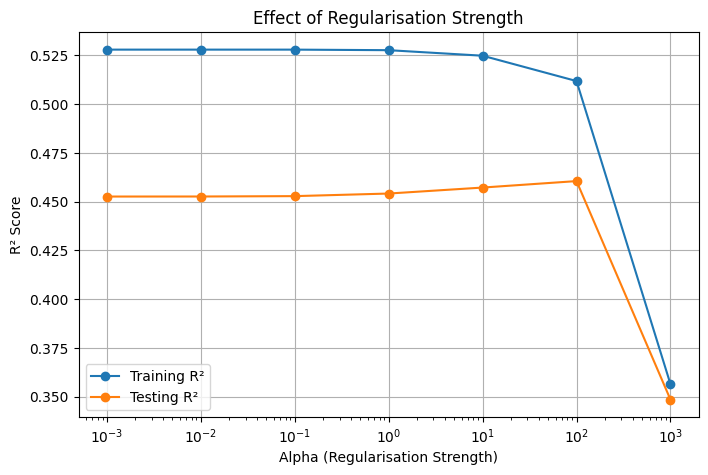

In [15]:
alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

train_scores = []
test_scores = []

for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(
        r2_score(y_train, train_pred)
    )

    test_scores.append(
        r2_score(y_test, test_pred)
    )

plt.figure(figsize=(8, 5))

plt.semilogx(
    alphas,
    train_scores,
    marker="o",
    label="Training R²"
)

plt.semilogx(
    alphas,
    test_scores,
    marker="o",
    label="Testing R²"
)

plt.xlabel("Alpha (Regularisation Strength)")
plt.ylabel("R² Score")
plt.title("Effect of Regularisation Strength")
plt.legend()
plt.grid()

plt.show()

In [16]:
mlflow.set_experiment("W4D2_Bias_Variance_Regularisation")

with mlflow.start_run():

    best_model = ridge_grid.best_estimator_

    predictions = best_model.predict(X_test)

    test_mse = mean_squared_error(
        y_test,
        predictions
    )

    test_mae = mean_absolute_error(
        y_test,
        predictions
    )

    test_r2 = r2_score(
        y_test,
        predictions
    )

    best_alpha = ridge_grid.best_params_[
        "model__alpha"
    ]

    # Log parameters
    mlflow.log_param(
        "model",
        "Ridge Regression"
    )

    mlflow.log_param(
        "cv_folds",
        5
    )

    mlflow.log_param(
        "best_alpha",
        best_alpha
    )

    # Log metrics
    mlflow.log_metric(
        "test_mse",
        test_mse
    )

    mlflow.log_metric(
        "test_mae",
        test_mae
    )

    mlflow.log_metric(
        "test_r2",
        test_r2
    )

    # Log model
    mlflow.sklearn.log_model(
        best_model,
        "ridge_model"
    )

    print("MLflow tracking completed!")

2026/08/25 15:22:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/25 15:22:37 INFO mlflow.store.db.utils: Updating database tables
2026/08/25 15:22:41 INFO mlflow.tracking.fluent: Experiment with name 'W4D2_Bias_Variance_Regularisation' does not exist. Creating a new experiment.
2026/08/25 15:22:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow tracking completed!


In [17]:
final_results = pd.DataFrame({
    "Metric": [
        "Best Alpha",
        "Test MSE",
        "Test MAE",
        "Test R²",
        "Mean CV R²"
    ],
    "Value": [
        best_alpha,
        test_mse,
        test_mae,
        test_r2,
        cv_scores.mean()
    ]
})

display(final_results)

,Metric,Value
0,Best Alpha,10.000000
1,Test MSE,2875.778718
2,Test MAE,42.856825
3,Test R²,0.457211
4,Mean CV R²,0.453937
